In [14]:
import glob
import os
import random
import numpy as np
import pandas as pd

root_path = "BreaKHis_v1/histology_slides/breast" # MacOS compatible path, may not work on Windows without modification

# Get the main path of the dataset



In [15]:
import glob
import os
from pathlib import Path

BASE_DIR = Path.cwd()
path_db = BASE_DIR / "BreaKHis_v1" / "histology_slides" / "breast"

def prepare_data_table(rootpath=path_db) -> pd.DataFrame:
    rootpath = Path(rootpath)

    # cross-platform recursive PNG search
    files = list(rootpath.rglob("*.png"))

    if not files:
        raise FileNotFoundError(f"No PNG files found under: {rootpath}")

    datas = []
    bad_files = []

    for f in files:
        try:
            datas.append(packup_details(f))
        except Exception as e:
            bad_files.append((str(f), str(e)))

    df = pd.DataFrame(datas)

    print("DataFrame shape:", df.shape)
    print("DataFrame columns:", df.columns.tolist())
    print("Parsed files:", len(datas))
    print("Failed files:", len(bad_files))

    if bad_files:
        print("\nFirst 10 problematic files:")
        for fp, err in bad_files[:10]:
            print(fp, "->", err)

    return df

def packup_details(f):
    p = Path(f)

    # only filename, cross-platform safe
    filename = p.name                          # SOB_B_A-14-22549G-100-001.png
    stem = p.stem                             # SOB_B_A-14-22549G-100-001

    parts = stem.split("_")
    if len(parts) < 3:
        raise ValueError(f"Unexpected filename format: {filename}")

    example = parts[0]                        # SOB
    is_malign = 1 if parts[1] == "M" else 0   # M -> malignant, B -> benign

    names = parts[2].split("-")
    if len(names) < 5:
        raise ValueError(f"Unexpected tumor name format: {filename}")

    class_tumor = names[0]
    year = int(names[1]) + 2000
    patient_id = names[2]
    zoom = int(names[3])
    file_id = names[4]

    return {
        "patient_id": patient_id,
        "file_id": file_id,
        "example": example,
        "class": class_tumor,
        "year": year,
        "zoom": zoom,
        "file_path": str(p),
        "is_malign": is_malign,
    }

In [16]:

# Get the data table and print its info and head

df = prepare_data_table(rootpath=root_path)

df.info()

df.head()

DataFrame shape: (7909, 8)
DataFrame columns: ['patient_id', 'file_id', 'example', 'class', 'year', 'zoom', 'file_path', 'is_malign']
Parsed files: 7909
Failed files: 0
<class 'pandas.DataFrame'>
RangeIndex: 7909 entries, 0 to 7908
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   patient_id  7909 non-null   str  
 1   file_id     7909 non-null   str  
 2   example     7909 non-null   str  
 3   class       7909 non-null   str  
 4   year        7909 non-null   int64
 5   zoom        7909 non-null   int64
 6   file_path   7909 non-null   str  
 7   is_malign   7909 non-null   int64
dtypes: int64(3), str(5)
memory usage: 494.4 KB


,patient_id,file_id,example,class,year,zoom,file_path,is_malign
0,13418DE,009,SOB,MC,2014,100,BreaKHis_v1/histology_slides/breast/malignant/...,1
1,13418DE,008,SOB,MC,2014,100,BreaKHis_v1/histology_slides/breast/malignant/...,1
2,13418DE,003,SOB,MC,2014,100,BreaKHis_v1/histology_slides/breast/malignant/...,1
3,13418DE,002,SOB,MC,2014,100,BreaKHis_v1/histology_slides/breast/malignant/...,1
4,13418DE,014,SOB,MC,2014,100,BreaKHis_v1/histology_slides/breast/malignant/...,1


In [17]:
df.describe()
# Check the details of numeric columns

,year,zoom,is_malign
count,7909.000000,7909.000000,7909.000000
mean,2014.008218,179.352636,0.686433
std,0.090288,133.676035,0.463972
min,2014.000000,40.000000,0.000000
25%,2014.000000,40.000000,0.000000
50%,2014.000000,100.000000,1.000000
75%,2014.000000,200.000000,1.000000
max,2015.000000,400.000000,1.000000


In [18]:

total_dataset = df[["is_malign","patient_id"]].groupby("patient_id").mean()
# patients which their images are all benign or all malignant

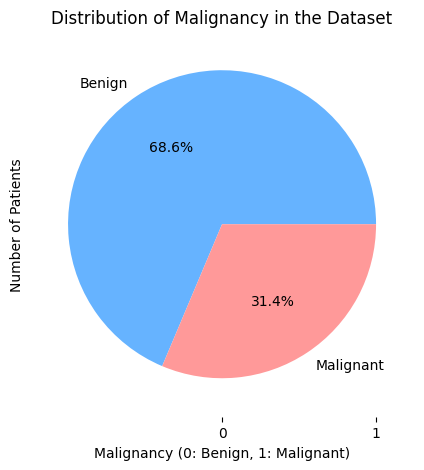

In [19]:
# Distribution of malignancy in the dataset
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.pie(df["is_malign"].value_counts(), labels=["Benign", "Malignant"], autopct="%1.1f%%", colors=["#66b3ff", "#ff9999"])
plt.title("Distribution of Malignancy in the Dataset")
plt.xlabel("Malignancy (0: Benign, 1: Malignant)")
plt.ylabel("Number of Patients")
plt.xticks([0, 1])
plt.grid(axis="y", alpha=0.75)
plt.show()

In [20]:
# Average number of images per patient
avg_images_per_patient = df.groupby("patient_id").size().mean()
print(f"Average number of images per patient: {avg_images_per_patient:.2f}")

Average number of images per patient: 97.64


In [21]:
df[df["is_malign"] == 1]["class"].unique() # number of patients with malignant samples
df[df["is_malign"] == 0]["class"].unique() # number of patients with benign samples

<StringArray>
['A', 'TA', 'F', 'PT']
Length: 4, dtype: str

In [22]:
def show_class_samples_by_zoom(dataframe, selected_zoom, n_cols=4, random_sample=False):
    zoom_df = dataframe[dataframe["zoom"] == selected_zoom].copy()

    if zoom_df.empty:
        print(f"No data found for zoom={selected_zoom}")
        return

    if random_sample:
        sample_per_class = zoom_df.sample(frac=1).reset_index(drop=True)
    else:
        sample_per_class = zoom_df.groupby("class", as_index=False).first()

    classes = sorted(sample_per_class["class"].unique())
    n_classes = len(classes)
    n_rows = int(np.ceil(n_classes / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, cls in enumerate(classes):
        ax = axes[i]
        row = sample_per_class[sample_per_class["class"] == cls].iloc[0]
        image_path = row["file_path"]

        if os.path.isfile(image_path):
            img = plt.imread(image_path)
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, f"Missing file\n{cls}", ha="center", va="center")

        ax.set_title(f"Class: {cls}")
        ax.axis("off")

    for j in range(n_classes, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"One sample per class at {selected_zoom}x zoom", y=1.02)
    plt.tight_layout()
    plt.show()

In [23]:
df["class"].unique()

<StringArray>
['MC', 'PC', 'DC', 'LC', 'A', 'TA', 'F', 'PT']
Length: 8, dtype: str

In [24]:
df["patient_id"].unique()

<StringArray>
['13418DE',   '16456',   '12773',  '19979C',   '18842',  '18842D',   '13413',
   '19979',   '10147',   '190EF',   '15704',   '19440',   '12465',  '15687B',
    '9146',   '11951',    '8168',   '12312',   '15792',   '16188',    '2985',
   '17915',   '17901',   '14926',   '16875',   '15696',   '16448',   '10926',
   '18650',   '20636',    '4372',   '16336',    '3909',   '13412',    '4364',
    '5287',   '20629',   '16716',   '14015',   '16601',    '2523',    '2773',
    '2980',   '11031',   '13993',   '14946',   '15572',    '5694',    '6241',
   '11520',    '5695',   '17614',    '9461',   '16196',   '15570',  '15570C',
   '12204', '22549AB',  '22549G', '22549CD', '29960CD', '16184CD',   '16184',
   '13200',   '15275', '21978AB',   '3411F',  '19854C', '29960AB', '23222AB',
   '14134',    '9133', '23060CD', '21998CD',   '25197', '21998EF',  '14134E',
 '23060AB',   '22704', '21998AB', '29315EF']
Length: 81, dtype: str

In [25]:
def show_class_samples_by_patient(dataframe, n_cols=4, patient_id=None):

    # --------------------------------------------------
    # 1. Patient ID al
    # --------------------------------------------------

    if patient_id is None:
        patient_id = np.random.choice(dataframe["patient_id"].unique())

    patient_df = dataframe[dataframe["patient_id"] == patient_id].copy()

    if patient_df.empty:
        print(f"[ERROR] Patient ID '{patient_id}' bulunamadı.")
        print(f"Mevcut hasta sayısı: {dataframe['patient_id'].nunique()}")
        print(f"Örnek ID'ler: {dataframe['patient_id'].unique()[:5].tolist()}")
        return

    # --------------------------------------------------
    # 2. Hasta bilgisi
    # --------------------------------------------------
    cls        = patient_df["class"].iloc[0]
    zooms      = sorted(patient_df["zoom"].unique())
    n_zooms    = len(zooms)
    n_images   = len(patient_df)

    print(f"\nPatient ID  : {patient_id}")
    print(f"Class       : {cls}")
    print(f"Zoom levels : {zooms}")
    print(f"Total images: {n_images}")

    # --------------------------------------------------
    # 3. Her zoom'dan 1 örnek seç
    # --------------------------------------------------
    samples = []
    for zoom in zooms:
        zoom_df = patient_df[patient_df["zoom"] == zoom]
        row     = zoom_df.sample(1, random_state=42).iloc[0]
        samples.append(row)

    # --------------------------------------------------
    # 4. Plot
    # --------------------------------------------------
    n_cols  = min(n_cols, n_zooms)
    n_rows  = int(np.ceil(n_zooms / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4 * n_cols, 4 * n_rows),
        squeeze=False
    )
    axes_flat = axes.flatten()

    for i, row in enumerate(samples):
        ax         = axes_flat[i]
        zoom_level = row["zoom"]
        fpath      = row["file_path"]
        n_in_zoom  = len(patient_df[patient_df["zoom"] == zoom_level])

        if os.path.isfile(fpath):
            img = plt.imread(fpath)
            ax.imshow(img)
            ax.set_title(
                f"{zoom_level}x zoom\n({n_in_zoom} görüntü)",
                fontsize=11
            )
        else:
            ax.text(
                0.5, 0.5,
                f"Dosya bulunamadı\n{zoom_level}x",
                ha="center", va="center",
                transform=ax.transAxes,
                fontsize=10
            )
            ax.set_title(f"{zoom_level}x zoom", fontsize=11)

        ax.axis("off")

    # Boş eksenler kapat
    for j in range(n_zooms, len(axes_flat)):
        axes_flat[j].axis("off")

    plt.suptitle(
        f"Patient {patient_id}  |  Class: {cls}  |  "
        f"Her zoom'dan 1 örnek",
        fontsize=13, y=1.02
    )
    plt.tight_layout()
    plt.show()




Patient ID  : 4372
Class       : DC
Zoom levels : [40, 100, 200, 400]
Total images: 84


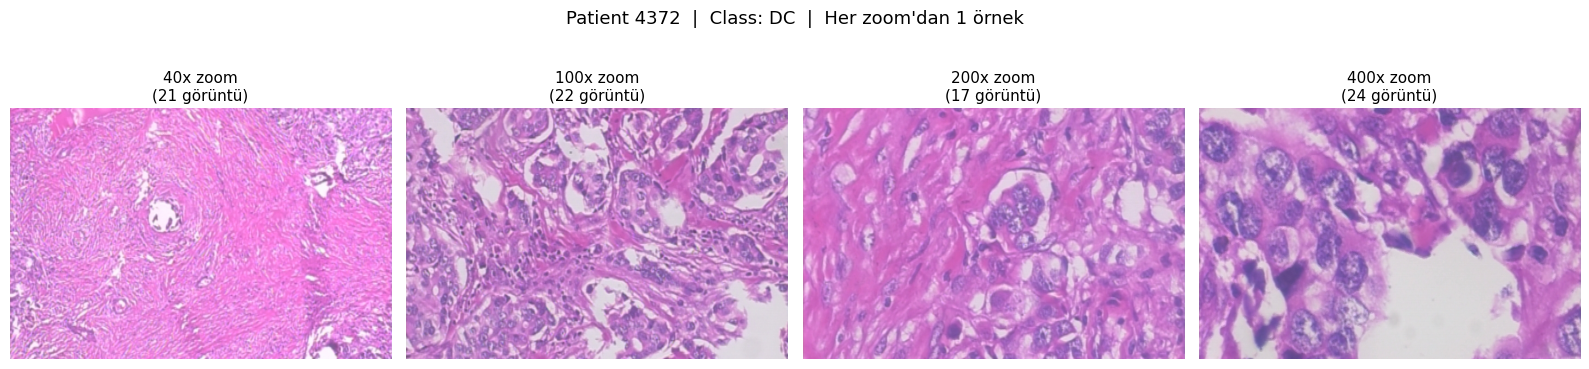

In [26]:
show_class_samples_by_patient(df)

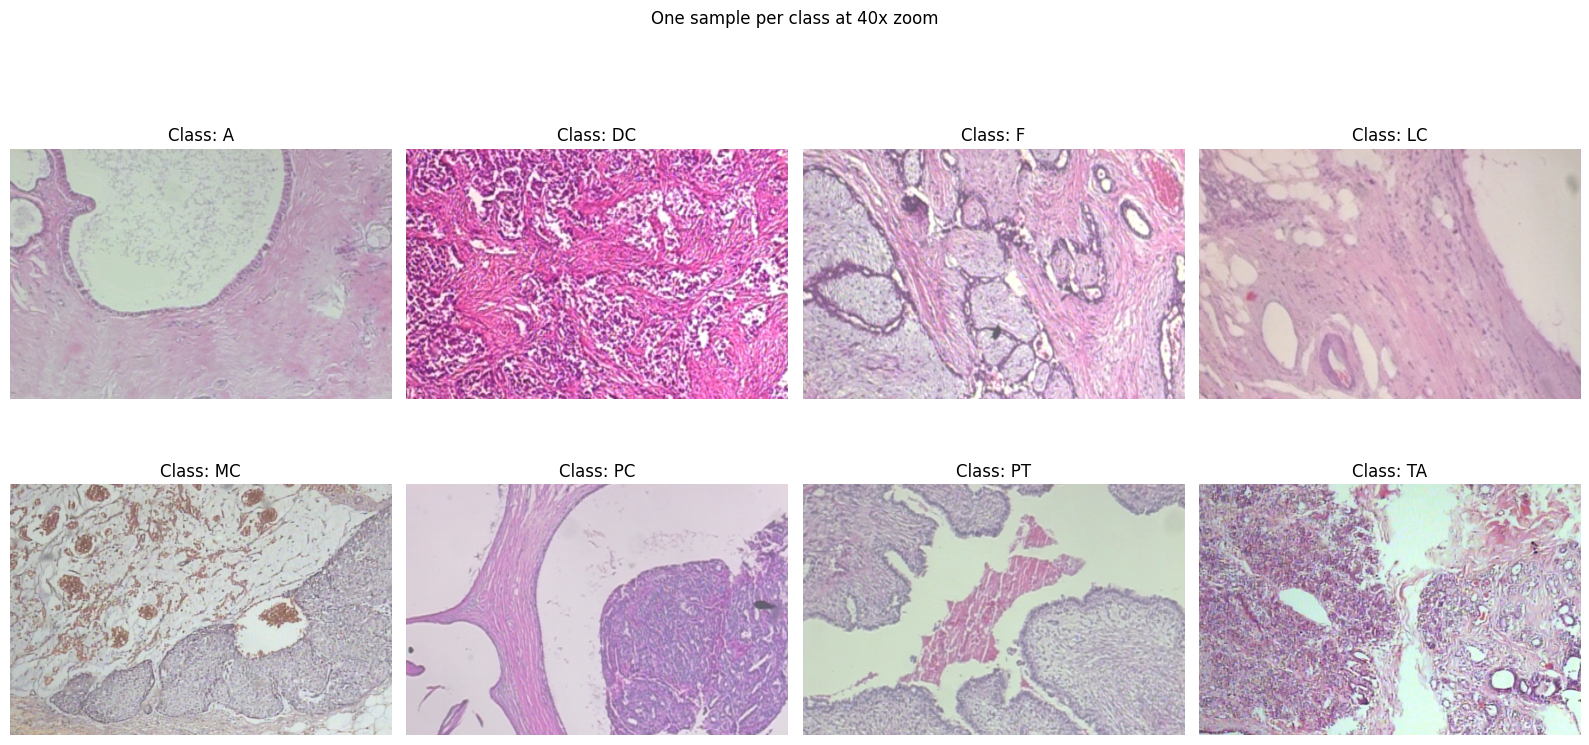

In [27]:
show_class_samples_by_zoom(df, selected_zoom=40, n_cols=4, random_sample=True)

In [28]:
df["is_malign"].value_counts()



is_malign
1    5429
0    2480
Name: count, dtype: int64

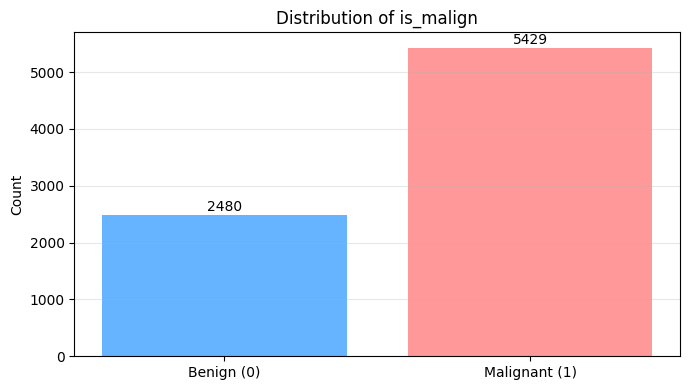

In [29]:
counts = df["is_malign"].value_counts().sort_index()  # 0: Benign, 1: Malignant

plt.figure(figsize=(7, 4))
bars = plt.bar(
    ["Benign (0)", "Malignant (1)"],
    [counts.get(0, 0), counts.get(1, 0)],
    color=["#66b3ff", "#ff9999"]
)

plt.title("Distribution of is_malign")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 20, f"{int(h)}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [30]:
df["class"].value_counts()

class
DC    3451
F     1014
MC     792
LC     626
TA     569
PC     560
PT     453
A      444
Name: count, dtype: int64

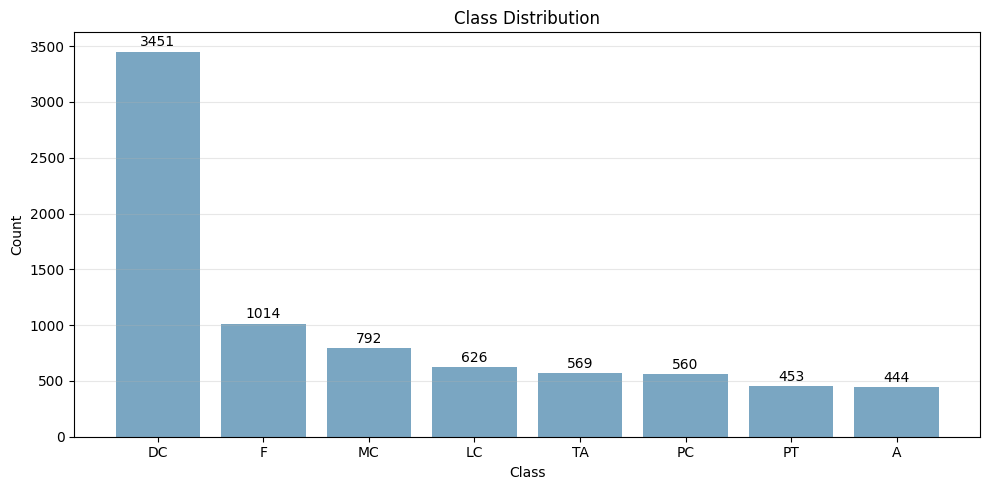

In [31]:
class_counts = df["class"].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.bar(class_counts.index, class_counts.values, color="#7aa6c2")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 20, f"{int(h)}", ha="center", va="bottom")

plt.tight_layout()
plt.show()